/mnt/c/Users/pelag/Documents/book popularity/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


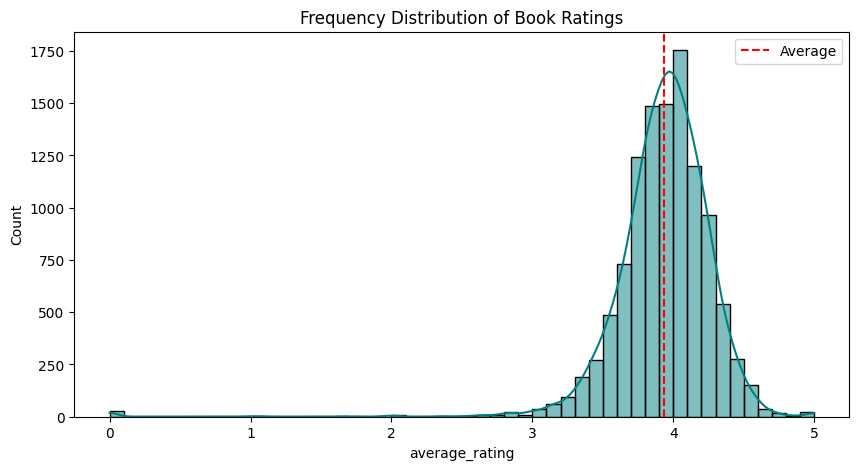

/tmp/ipykernel_25284/1933710233.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rated_popular, x='average_rating', y='title', palette='magma')


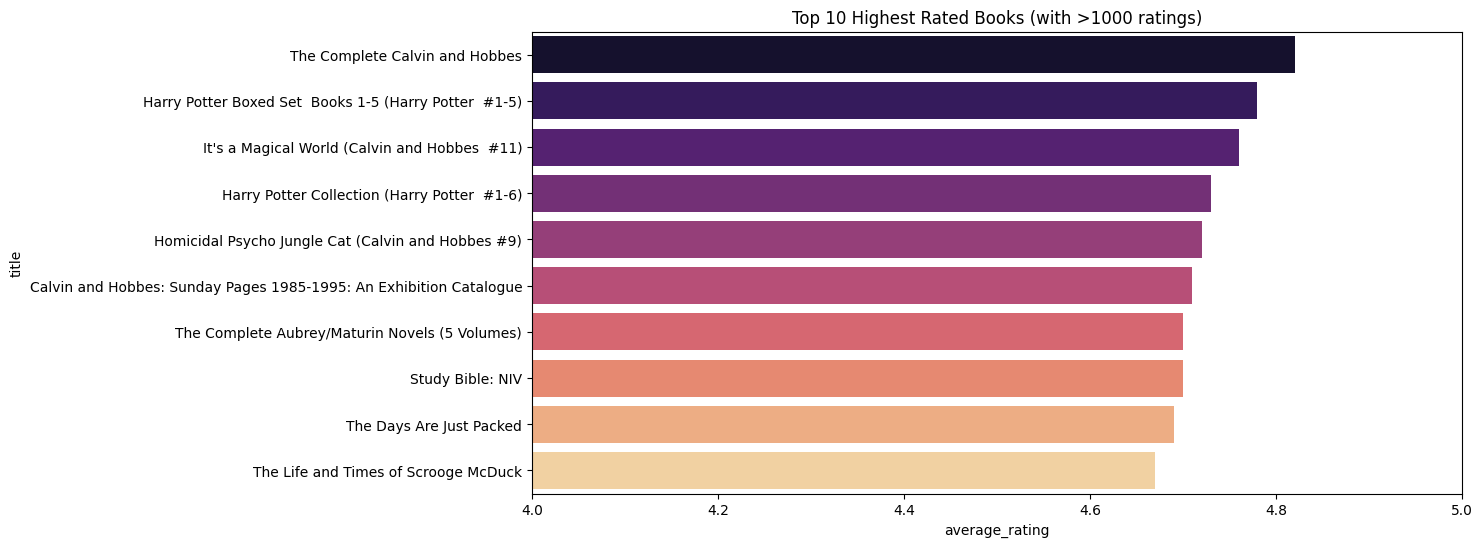

A book needs 745.0 ratings to be considered 'Popular' in this dataset.
Columns selected and split into training and testing sets successfully
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1093
           1       0.92      0.91      0.91      1132

    accuracy                           0.91      2225
   macro avg       0.91      0.91      0.91      2225
weighted avg       0.91      0.91      0.91      2225



/tmp/ipykernel_25284/1933710233.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


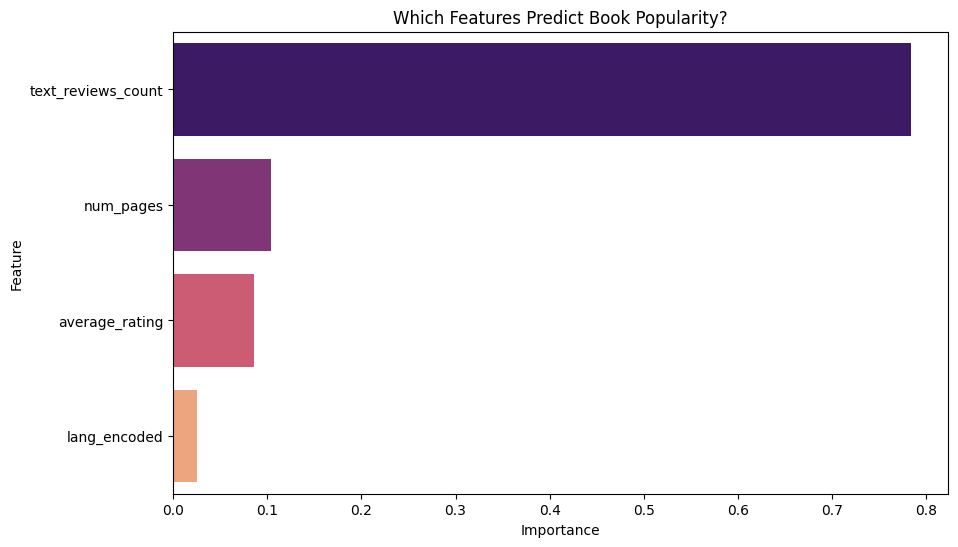

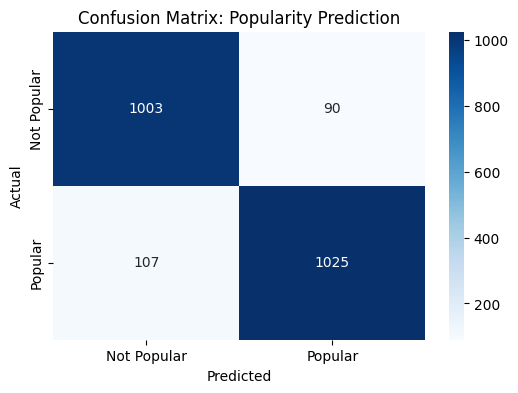

In [1]:
import os
from turtle import pd
from dotenv import load_dotenv
load_dotenv()

import kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

kaggle.api.authenticate()

books = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    handle="jealousleopard/goodreadsbooks",
    path="books.csv",
    pandas_kwargs={
        "on_bad_lines": "skip",  #This skips the rows with formatting errors
        "encoding": "utf-8"      #Ensures special characters in titles don't break it
    }
)
#Frequency distribution of ratings using histplot
plt.figure(figsize=(10, 5))
sns.histplot(books['average_rating'], bins=50, color='teal', kde=True)
plt.axvline(books['average_rating'].mean(), color='red', linestyle='--', label='Average')
plt.title('Frequency Distribution of Book Ratings')
plt.legend()
plt.show()

#Most popular books with more than 1000 ratings
popular_books = books[books['ratings_count'] > 1000]
top_rated_popular = popular_books.sort_values('average_rating', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_rated_popular, x='average_rating', y='title', palette='magma')
plt.xlim(4.0, 5.0) 
plt.title('Top 10 Highest Rated Books (with >1000 ratings)')
plt.show()

#Find the median number of ratings to split the data fairly
median_ratings = books['ratings_count'].median()

#Create our target column: 1 if popular, 0 if not
books['is_popular'] = (books['ratings_count'] > median_ratings).astype(int)
print(f"A book needs {median_ratings} ratings to be considered 'Popular' in this dataset.")

#Strip any leading/trailing whitespace from column names
books.columns = [col.strip() for col in books.columns]

le = LabelEncoder()
books['lang_encoded'] = le.fit_transform(books['language_code'])

#Define Features - Use the names exactly as they appear in books.columns
#Double check if 'text_reviews_count' also has a space if this fails!
X = books[['average_rating', 'num_pages', 'lang_encoded', 'text_reviews_count']]
y = books['is_popular']

#Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Columns selected and split into training and testing sets successfully")

#1.Initialize and Fit the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#2.Get Feature Importances
importances = model.feature_importances_
feature_names = X.columns

#3.Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
 
#4.Test the model
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

#5.Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Which Features Predict Book Popularity?')
plt.show()

#Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Popular', 'Popular'], yticklabels=['Not Popular', 'Popular'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Popularity Prediction')
plt.show()